**Prerequisites**

In [ ]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install scipy
!pip install seaborn
!pip install tensorflow
!pip install Flask

**EPIC 1 : DATA COLLECTION AND DATA PREPROCESSING**


Activity 1.1 Download the Dataset

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kritikasahhhhh","key":"75f00055057e9848c6809b90fabe14c5"}'}

In [ ]:
# Install required packages
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib

# Python imports & configuration
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# If dataset not downloaded yet, download & unzip (comment out if already present)
import os

if not os.path.exists("/content/new-plant-diseases-dataset"):
    !kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content
    !unzip -q /content/new-plant-diseases-dataset.zip -d /content/new-plant-diseases-dataset

# Confirm dataset presence (small print)
!ls -lah /content/new-plant-diseases-dataset | sed -n '1,200p'

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.68G/2.70G [00:28<00:00, 260MB/s]
100% 2.70G/2.70G [00:28<00:00, 101MB/s]
total 20K
drwxr-xr-x 5 root root 4.0K Mar  8 11:49 .
drwxr-xr-x 1 root root 4.0K Mar  8 11:48 ..
drwxr-xr-x 3 root root 4.0K Mar  8 11:48 new plant diseases dataset(augmented)
drwxr-xr-x 3 root root 4.0K Mar  8 11:48 New Plant Diseases Dataset(Augmented)
drwxr-xr-x 3 root root 4.0K Mar  8 11:49 test


Activity 1.2: Data Exploration and Visualization


In [ ]:
# User / experiment configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
N_LAST_LAYERS = 10   # Unfreeze last 10 layers for fine-tuning
SEED = 1337

# Dataset paths
train_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Verify paths exist
for p in [train_dir, valid_dir]:
    if not os.path.exists(p):
        print(f"ERROR: path not found: {p}")
        sys.exit(1)

print("train_dir:", train_dir)
print("valid_dir:", valid_dir)

train_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
valid_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid


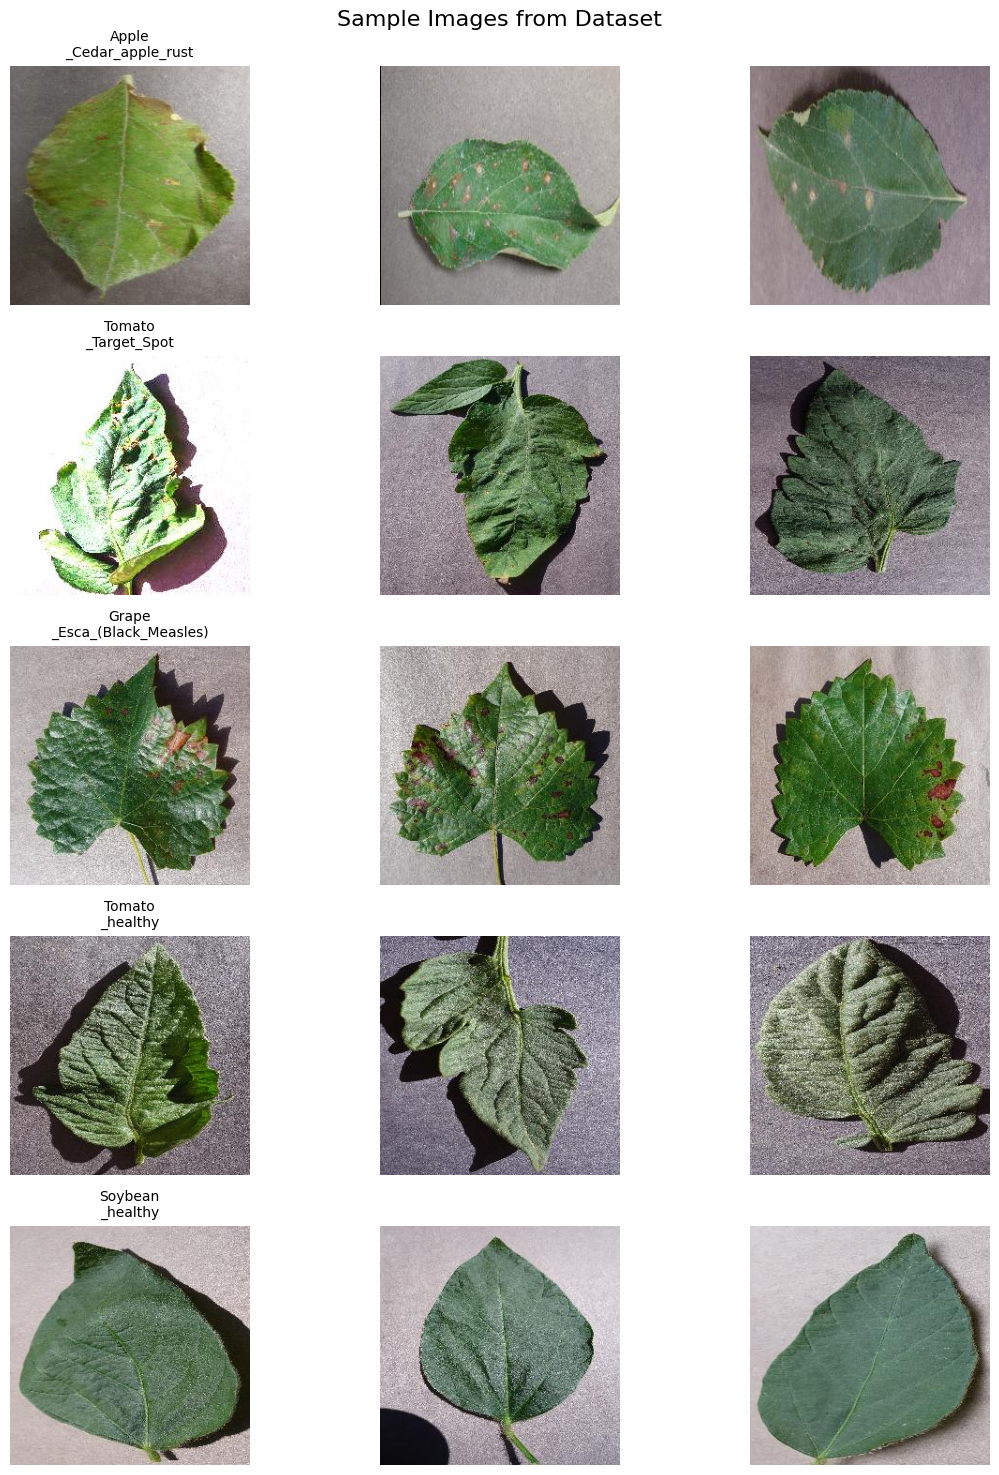

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Function to display random samples from each class
def show_sample_images(base_path, num_classes=5, images_per_class=3):
    """Display random sample images from the dataset"""

    class_names = os.listdir(base_path)
    random_classes = random.sample(class_names, min(num_classes, len(class_names)))

    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(12, 3*num_classes))
    fig.suptitle('Sample Images from Dataset', fontsize=16)

    for i, class_name in enumerate(random_classes):
        class_path = os.path.join(base_path, class_name)
        images = os.listdir(class_path)
        random_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(random_images):
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_title(class_name.replace('__', '\n'), fontsize=10)

    plt.tight_layout()
    plt.show()
show_sample_images(train_dir)

In [ ]:
# Count images in each split
def count_images(directory):
    """Count total images and images per class"""

    total_images = 0
    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    return total_images, class_counts


# Get statistics
train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(valid_dir)

print(f"Training images: {train_total}")
print(f"Validation images: {valid_total}")
print(f"Number of classes: {len(train_counts)}")

print("\nClass distribution (first 10):")
for i, (class_name, count) in enumerate(list(train_counts.items())[:10]):
    print(f"  {class_name}: {count} images")

Training images: 70295
Validation images: 17572
Number of classes: 38

Class distribution (first 10):
  Soybean___healthy: 2022 images
  Cherry_(including_sour)___healthy: 1826 images
  Blueberry___healthy: 1816 images
  Potato___Early_blight: 1939 images
  Tomato___healthy: 1926 images
  Strawberry___Leaf_scorch: 1774 images
  Peach___healthy: 1728 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961 images
  Squash___Powdery_mildew: 1736 images
  Tomato___Septoria_leaf_spot: 1745 images


Activity 1.3: Data Preprocessing and Augmentation

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training data generator with light augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

# Validation data generator (no augmentation)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


**Epic 2: MODEL BUILDING**


Activity 2.2: Load Pre-trained MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

Activity 2.3 : Configure Transfer Learning Strategy

In [ ]:
# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last N layers for fine-tuning
if N_LAST_LAYERS > 0:
    for layer in base_model.layers[-N_LAST_LAYERS:]:
        layer.trainable = True

# Count trainable parameters
trainable_count = sum([tf.size(w).numpy() for w in base_model.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in base_model.non_trainable_weights])

print(f"Trainable parameters: {trainable_count:,}")
print(f"Non-trainable parameters: {non_trainable_count:,}")
print(f"Unfrozen last {N_LAST_LAYERS} layers for fine-tuning")

Trainable parameters: 732,480
Non-trainable parameters: 1,525,504
Unfrozen last 10 layers for fine-tuning


In [ ]:
NUM_CLASSES = len(train_counts)
inputs = keras.Input(shape=IMG_SIZE + (3,))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="mobilenetv2_plant_disease_classifier")

model.summary()

Model: "mobilenetv2_plant_disease_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 1,070,182 (4.08 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

**Epic 3: Model Training**

Activity 3.1 : Compile the Model

In [ ]:
# Compile model with appropriate settings
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Low learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam (lr=1e-4)
Loss function: Categorical Crossentropy
Metrics: Accuracy


Activity 3.2 : Setup Training Callbacks

In [ ]:
# Define training callbacks
callbacks = [
    # Save best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        "content/mobilenetv2_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    # Stop training if no improvement
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("  1. ModelCheckpoint - Saves best model")
print("  2. ReduceLROnPlateau - Adjusts learning rate")
print("  3. EarlyStopping - Prevents overfitting")

Callbacks configured:
  1. ModelCheckpoint - Saves best model
  2. ReduceLROnPlateau - Adjusts learning rate
  3. EarlyStopping - Prevents overfitting


In [ ]:
# Data augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only rescaling for validation data
valid_datagen = ImageDataGenerator(rescale=1./255)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# Validation data generator
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[]


In [ ]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=300,
    validation_steps=50
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7703 - loss: 0.7445
Epoch 1: val_accuracy improved from -inf to 0.67000, saving model to content/mobilenetv2_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.7703 - loss: 0.7442 - val_accuracy: 0.6700 - val_loss: 1.1849 - learning_rate: 1.0000e-04
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8306 - loss: 0.5544
Epoch 2: val_accuracy did not improve from 0.67000
300/300 ━━━━━━━━━━━━━━━━━━━━ 657s 2s/step - accuracy: 0.8306 - loss: 0.5543 - val_accuracy: 0.6556 - val_loss: 1.3198 - learning_rate: 1.0000e-04
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8599 - loss: 0.4515
Epoch 3: val_accuracy improved from 0.67000 to 0.87375, saving model to content/mobilenetv2_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 682s 2s/step - accuracy: 0.8599 - loss: 0.4514 - val_accuracy: 0.8737 - val_loss: 0.4217 - learning_rate: 1.0000e-04
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accu

Activity 3.4

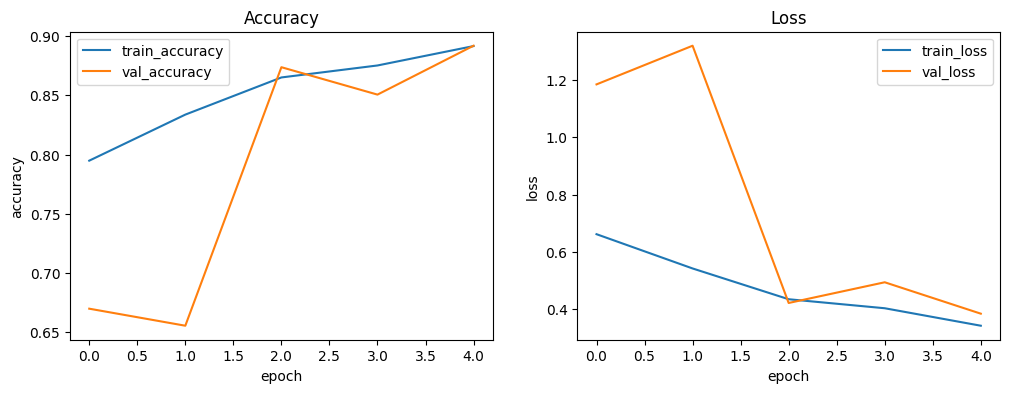

In [ ]:
import matplotlib.pyplot as plt

# -------------- Plot training curves ----------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train_accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')

plt.show()

**Epic 4: Model Evaluation and Testing**

In [ ]:
# 1. Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(valid_generator, verbose=1)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")


550/550 ━━━━━━━━━━━━━━━━━━━━ 761s 1s/step - accuracy: 0.9132 - loss: 0.3056
Final Validation Loss: 0.4335
Final Validation Accuracy: 0.8742


In [ ]:
# 2. Save the final model
model.save("plantcare_model_final.keras")
print("Model saved successfully as 'plantcare_model_final.keras'")

Model saved successfully as 'plantcare_model_final.keras'
